In [2]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv('Feature_extracted_train_data.csv')
df.head()

,Age,JobLevel,OverTime,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,YearsWithCurrManager,JobRole,Attrition
0,41,2,1,8,6,4,5,1,0
1,49,2,0,10,10,7,7,0,0
2,37,1,1,7,0,0,0,1,1
3,33,1,1,8,8,7,0,0,0
4,27,1,0,6,2,2,2,1,0


In [4]:
df.shape

(1676, 9)

In [5]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [8]:
display(X_train.shape)
display(X_test.shape)
display(y_train.shape)
display(y_test.shape)

(1340, 8)

(336, 8)

(1340,)

(336,)

### Cross Validation Application

In [27]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv2 = StratifiedKFold(n_splits=7, shuffle=True, random_state=42)
cv3 = StratifiedKFold(n_splits=9, shuffle=True, random_state=42)

In [11]:
import warnings
warnings.filterwarnings('ignore')

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import RocCurveDisplay, auc, roc_curve

In [13]:
cvs = [cv, cv2, cv3]

#### Graphing function

In [30]:
import matplotlib.pyplot as plt

In [34]:
def plot_custom_roc_cv(estimator, X, y, i, title="ROC Curve"):

    n_splits=(5 + ((cvs.index(i) + 1) - 1)*2)
    
    cv = StratifiedKFold(n_splits=n_splits)
    tprs = []
    aucs = []
    mean_fpr = np.linspace(0, 1, 100)

    fig, ax = plt.subplots(figsize=(8, 6))

    for fold, (train, test) in enumerate(cv.split(X, y)):
        estimator.fit(X.iloc[train], y.iloc[train])
        viz = RocCurveDisplay.from_estimator(
            estimator,
            X.iloc[test],
            y.iloc[test],
            name=f"ROC fold {fold}",
            alpha=0.3,
            lw=1,
            ax=ax,
        )
        interp_tpr = np.interp(mean_fpr, viz.fpr, viz.tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)
        aucs.append(viz.roc_auc)

    ax.plot([0, 1], [0, 1], "k--", label="Chance level (AUC = 0.5)")

    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = auc(mean_fpr, mean_tpr)
    std_auc = np.std(aucs)
    
    ax.plot(
        mean_fpr,
        mean_tpr,
        color="b",
        label=f"Mean ROC (AUC = {mean_auc:.2f} $\pm$ {std_auc:.2f})",
        lw=2,
        alpha=0.8,
    )

    ax.set(
        xlim=[-0.05, 1.05],
        ylim=[-0.05, 1.05],
        xlabel="False Positive Rate",
        ylabel="True Positive Rate",
        title=title,
    )
    ax.legend(loc="lower right")
    plt.show()

    classification_report(y_test, y_pred_binary)
    
    return mean_auc

In [35]:
lr_score_list = []
for i in cvs:
    lr = LogisticRegression(max_iter=500, random_state=42)
    
    lr_scores = cross_val_score(
        lr,
        X_train,
        y_train,
        cv=i,
        scoring='roc_auc'
    )
    
    print(f'---- {5 + ((cvs.index(i) + 1) - 1)*2} cv n_splits----\n')
    print(f'LR CV ROC-AUC: {lr_scores}')
    print(f'Mean ROC-AUC : {lr_scores.mean()}\n\nRounded ROC-AUC: {round(lr_scores.mean(), 3)}')
    lr_score_list.append(lr_scores.mean())
    print()

max_lr_score = max(lr_score_list)
print(f'>>> Max lr_score = {round(max_lr_score, 3)}')

---- 5 cv n_splits----

LR CV ROC-AUC: [0.88954675 0.86089778 0.86030191 0.86414195 0.89976165]
Mean ROC-AUC : 0.8749300075350714

Rounded ROC-AUC: 0.875

---- 7 cv n_splits----

LR CV ROC-AUC: [0.83406226 0.9024955  0.88139954 0.83270576 0.84911243 0.88612836
 0.9055383 ]
Mean ROC-AUC : 0.8702060202896323

Rounded ROC-AUC: 0.87

---- 9 cv n_splits----

LR CV ROC-AUC: [0.84135472 0.90196078 0.86641221 0.89800679 0.81552163 0.8379983
 0.88888889 0.92027142 0.87965873]
Mean ROC-AUC : 0.8722303864872342

Rounded ROC-AUC: 0.872

>>> Max lr_score = 0.875



Generating plots for 5 n_splits...



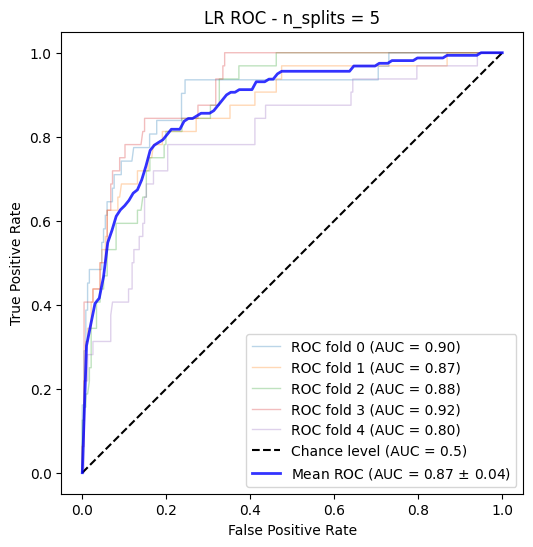


Generating plots for 7 n_splits...



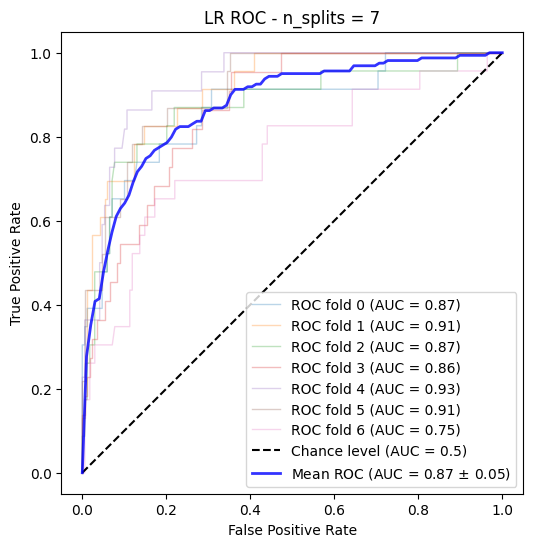


Generating plots for 9 n_splits...



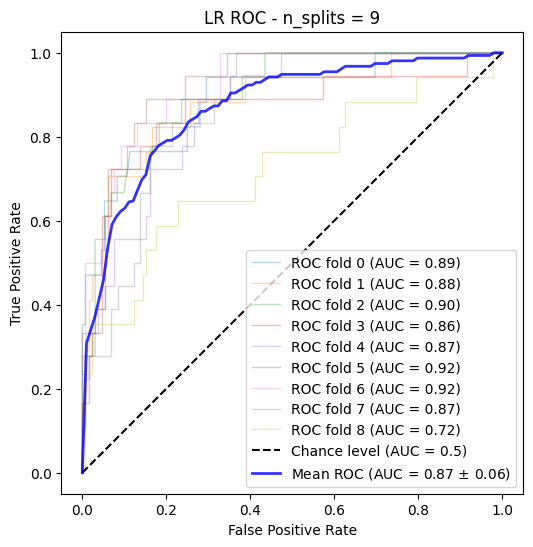

In [36]:
for i in cvs:
    print(f"\nGenerating plots for {5 + ((cvs.index(i) + 1) - 1)*2} n_splits...\n")
    mean_score = plot_custom_roc_cv(lr, X_train, y_train, i, title=f"LR ROC - n_splits = {5 + ((cvs.index(i) + 1) - 1)*2}")
    lr_score_list.append(mean_score)
del lr_score_list

In [37]:
rf_score_list = []
for i in cvs:
    rf = RandomForestClassifier(n_estimators=200, random_state=42)

    rf_scores = cross_val_score(
        rf,
        X_train,
        y_train,
        cv=i,
        scoring='roc_auc'
    )
    
    print(f'---- {5 + ((cvs.index(i) + 1) - 1)*2} cv n_splits----\n')
    print(f'RFC CV ROC-AUC: {rf_scores}')
    print(f'Mean ROC-AUC : {rf_scores.mean()}\n\nRounded ROC-AUC: {round(rf_scores.mean(), 3)}')
    rf_score_list.append(rf_scores.mean())
    print()

max_rf_score = max(rf_score_list)
print(f'>>> Max rf_score = {round(max_rf_score, 3)}')

---- 5 cv n_splits----

RFC CV ROC-AUC: [0.89015925 0.85626324 0.88618909 0.85924258 0.89155191]
Mean ROC-AUC : 0.8766812141413652

Rounded ROC-AUC: 0.877

---- 7 cv n_splits----

RFC CV ROC-AUC: [0.84756882 0.90596861 0.8497556  0.88918774 0.81118881 0.89492754
 0.89984472]
Mean ROC-AUC : 0.8712059759001946

Rounded ROC-AUC: 0.871

---- 9 cv n_splits----

RFC CV ROC-AUC: [0.87678253 0.89416221 0.83439355 0.92684478 0.85474979 0.82103478
 0.89525021 0.92324003 0.84777728]
Mean ROC-AUC : 0.8749150185686632

Rounded ROC-AUC: 0.875

>>> Max rf_score = 0.877



Generating plots for 5 n_splits...



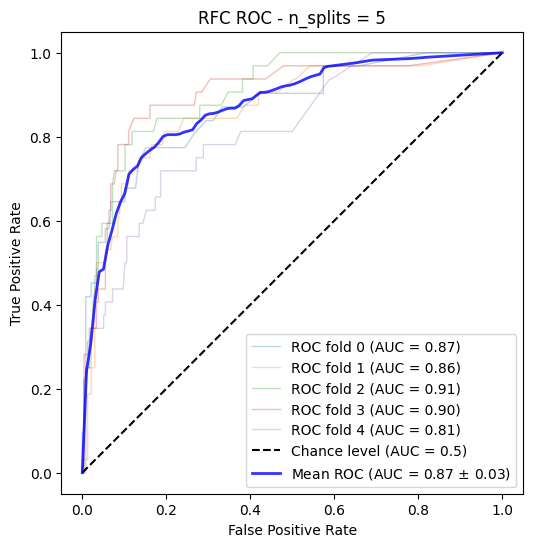


Generating plots for 7 n_splits...



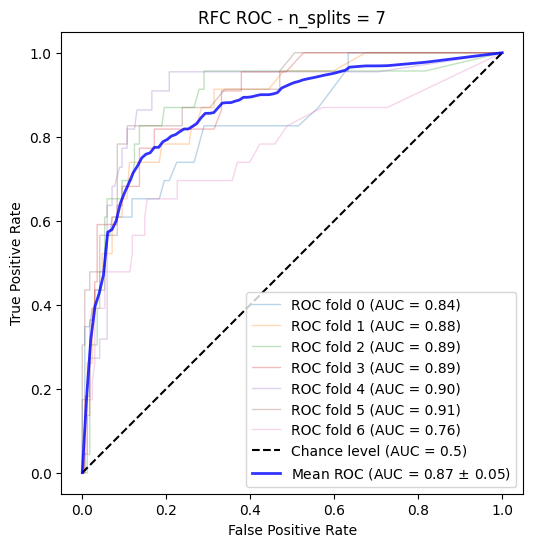


Generating plots for 9 n_splits...



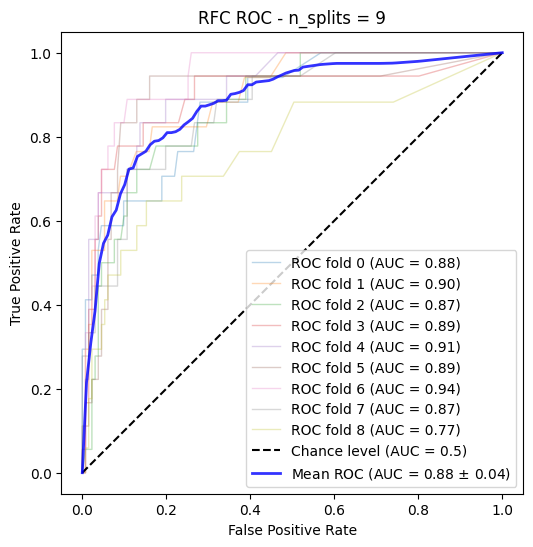

In [38]:
for i in cvs:
    print(f"\nGenerating plots for {5 + ((cvs.index(i) + 1) - 1)*2} n_splits...\n")
    mean_score = plot_custom_roc_cv(rf, X_train, y_train, i, title=f"RFC ROC - n_splits = {5 + ((cvs.index(i) + 1) - 1)*2}")
    rf_score_list.append(mean_score)
del rf_score_list

In [39]:
gb_score_list = []
for i in cvs:
    gb = GradientBoostingClassifier(random_state=42)
    
    gb_scores = cross_val_score(
        gb,
        X_train,
        y_train,
        cv=i,
        scoring='roc_auc'
    )
    
    print(f'---- {5 + ((cvs.index(i) + 1) - 1)*2} cv n_splits----\n')
    print(f'GB CV ROC-AUC: {gb_scores}')
    print(f'Mean ROC-AUC : {gb_scores.mean()}\n\nRounded ROC-AUC: {round(gb_scores.mean(), 3)}')
    gb_score_list.append(gb_scores.mean())
    print()

max_gb_score = max(gb_score_list)
print(f'>>> Max gb_score = {round(max_gb_score, 3)}')

---- 5 cv n_splits----

GB CV ROC-AUC: [0.8894787  0.88042903 0.89300847 0.88506356 0.92935646]
Mean ROC-AUC : 0.8954672439950123

Rounded ROC-AUC: 0.895

---- 7 cv n_splits----

GB CV ROC-AUC: [0.85464368 0.91188577 0.895292   0.87170522 0.85556751 0.89078675
 0.93400621]
Mean ROC-AUC : 0.8876981634387272

Rounded ROC-AUC: 0.888

---- 9 cv n_splits----

GB CV ROC-AUC: [0.86296791 0.91488414 0.88507209 0.91284987 0.85793045 0.84775233
 0.91475827 0.94020356 0.9039066 ]
Mean ROC-AUC : 0.8933694702853511

Rounded ROC-AUC: 0.893

>>> Max gb_score = 0.895



Generating plots for 5 n_splits...



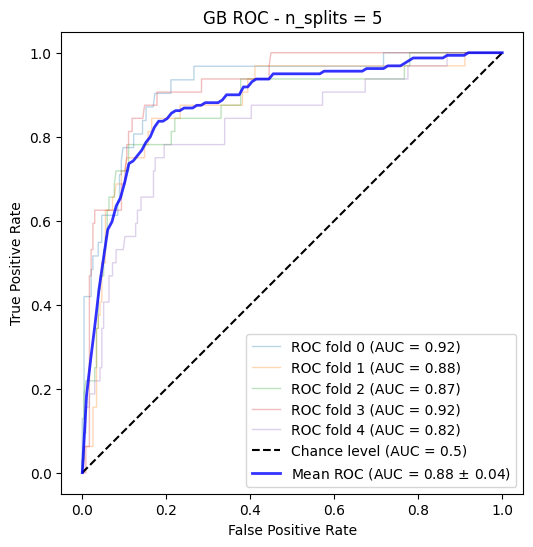


Generating plots for 7 n_splits...



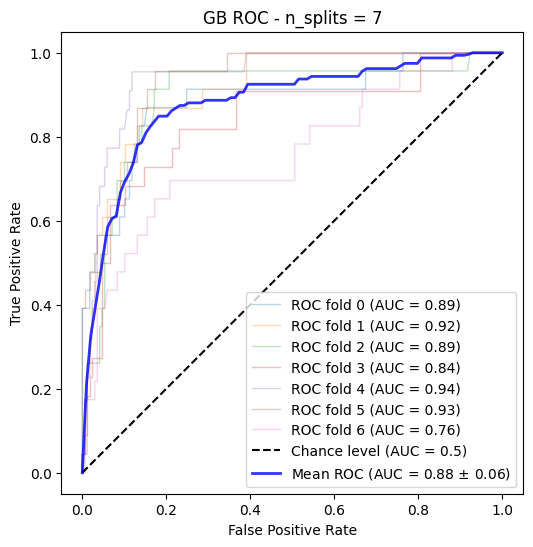


Generating plots for 9 n_splits...



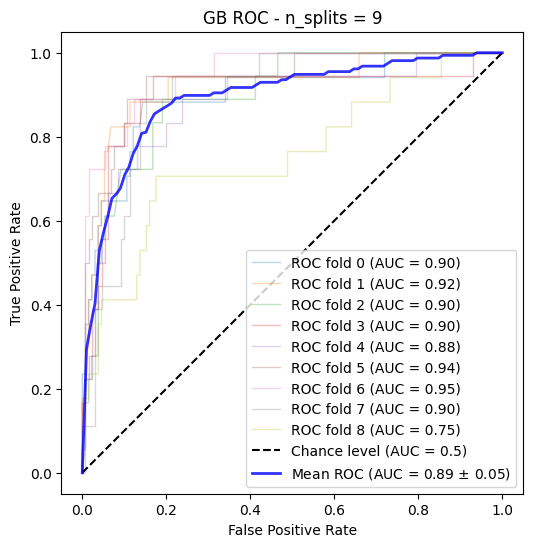

In [40]:
for i in cvs:
    print(f"\nGenerating plots for {5 + ((cvs.index(i) + 1) - 1)*2} n_splits...\n")
    mean_score = plot_custom_roc_cv(gb, X_train, y_train, i, title=f"GB ROC - n_splits = {5 + ((cvs.index(i) + 1) - 1)*2}")
    gb_score_list.append(mean_score)
del gb_score_list

In [41]:
xgb_score_list = []
for i in cvs:
    xgb = XGBClassifier(n_estimators=200, random_state=42)
    
    xgb_scores = cross_val_score(
        xgb,
        X_train,
        y_train,
        cv=i,
        scoring='roc_auc'
    )
    
    print(f'---- {5 + ((cvs.index(i) + 1) - 1)*2} cv n_splits----\n')
    print(f'XGB CV ROC-AUC: {xgb_scores}')
    print(f'Mean ROC-AUC : {xgb_scores.mean()}\n\nRounded ROC-AUC: {round(xgb_scores.mean(), 3)}')
    xgb_score_list.append(xgb_scores.mean())
    print()

max_xgb_score = max(xgb_score_list)
print(f'>>> Max xgb_score = {round(max_xgb_score, 3)}')

---- 5 cv n_splits----

XGB CV ROC-AUC: [0.86654417 0.847259   0.85990466 0.85884534 0.91379767]
Mean ROC-AUC : 0.869270168283261

Rounded ROC-AUC: 0.869

---- 7 cv n_splits----

XGB CV ROC-AUC: [0.81708258 0.86313352 0.86287625 0.87170522 0.79128564 0.86749482
 0.92675983]
Mean ROC-AUC : 0.8571911246899303

Rounded ROC-AUC: 0.857

---- 9 cv n_splits----

XGB CV ROC-AUC: [0.87121212 0.83734403 0.82485157 0.91666667 0.8490246  0.80491942
 0.89609839 0.9245123  0.89672205]
Mean ROC-AUC : 0.8690390156113851

Rounded ROC-AUC: 0.869

>>> Max xgb_score = 0.869



Generating plots for 5 n_splits...



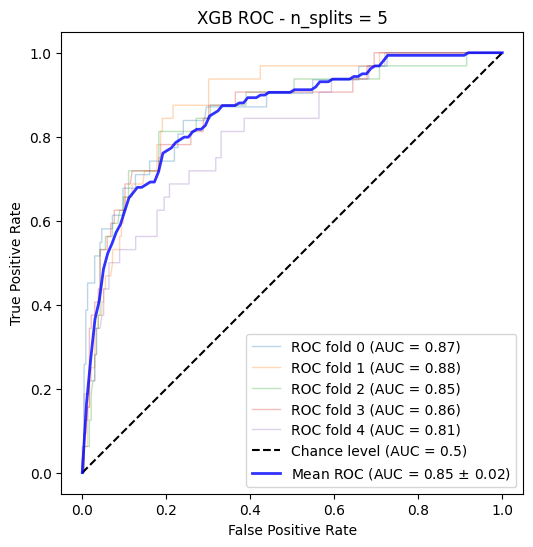


Generating plots for 7 n_splits...



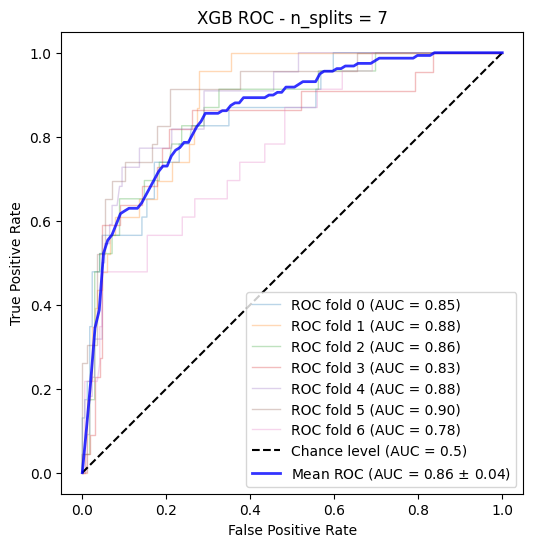


Generating plots for 9 n_splits...



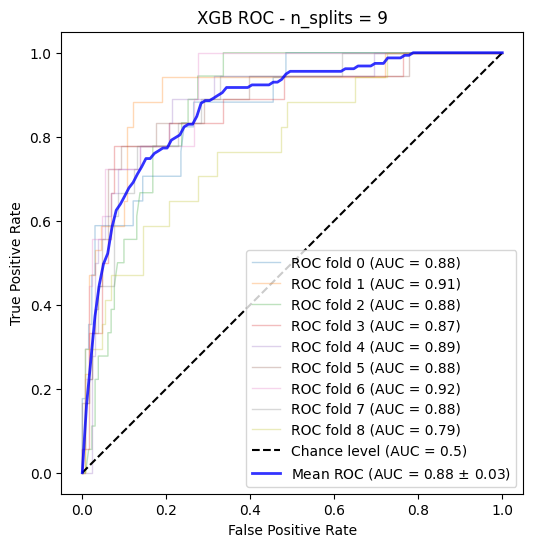

In [42]:
for i in cvs:
    print(f"\nGenerating plots for {5 + ((cvs.index(i) + 1) - 1)*2} n_splits...\n")
    mean_score = plot_custom_roc_cv(xgb, X_train, y_train, i, title=f"XGB ROC - n_splits = {5 + ((cvs.index(i) + 1) - 1)*2}")
    xgb_score_list.append(mean_score)
del xgb_score_list

In [20]:
LR_Score = round(max_lr_score.mean(), 3)
RF_Score = round(max_rf_score.mean(), 3)
GB_Score = round(max_gb_score.mean(), 3)
XGB_Score = round(max_xgb_score.mean(), 3)

In [21]:
Scores = {'Logistic Regression': LR_Score, 'Random Forest Classifier': RF_Score, 'Gradient Boosting Classifier': GB_Score, 'XGBoost': XGB_Score}
models = {'Logistic Regression': lr, 'Random Forest Classifier': rf, 'Gradient Boosting Classifier': gb, 'XGBoost': xgb}

best_model_name = max(Scores, key=Scores.get)
best_model = models[best_model_name]

print(f'The Best Model for Training is {best_model_name}')

The Best Model for Training is Gradient Boosting Classifier


### Gradient Boosting Classifier

In [23]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import log_loss

In [24]:
weights = compute_sample_weight(class_weight='balanced', y=y_train)

In [25]:
gbc = GradientBoostingClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 150],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 4],
    'subsample': [0.7, 0.9]
}

grid_search = GridSearchCV(
    gbc, 
    param_grid, 
    scoring='neg_log_loss', 
    cv=5
)

In [26]:
grid_search.fit(X_train, y_train, sample_weight=weights)

,estimator,GradientBoost...ndom_state=42)
,param_grid,"{'learning_rate': [0.05, 0.1], 'max_depth': [3, 4], 'n_estimators': [100, 150], 'subsample': [0.7, 0.9]}"
,scoring,'neg_log_loss'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'log_loss'


In [27]:
best_model = grid_search.best_estimator_
probs = best_model.predict_proba(X_test)[:, 1]

In [29]:
from sklearn.metrics import classification_report

In [30]:
print("\nClassification Report (at 0.5 threshold):")
print(classification_report(y_test, best_model.predict(X_test)))


Classification Report (at 0.5 threshold):
              precision    recall  f1-score   support

           0       0.95      0.86      0.90       296
           1       0.39      0.65      0.49        40

    accuracy                           0.84       336
   macro avg       0.67      0.76      0.70       336
weighted avg       0.88      0.84      0.86       336



### XGBoosting

In [31]:
pos_sum = (y_train == 1).sum()
neg_sum = (y_train == 0).sum()
display(pos_sum)
display(neg_sum)

np.int64(159)

np.int64(1181)

In [32]:
proportion = neg_sum / pos_sum
display(proportion)

np.float64(7.427672955974843)

In [33]:
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=1.0,
    scale_pos_weight=proportion,    
    eval_metric="logloss",
    random_state=42,
    use_label_encoder=False
)

param_grid = {
'max_depth': [3, 4, 5],
'learning_rate': [0.01, 0.05, 0.1],
'gamma': [0, 0.1, 0.2]      # Minimum loss reduction to make a split
}

grid_xgb = GridSearchCV(
            xgb,
            param_grid=param_grid,
            cv=5,
            scoring='neg_log_loss',    
            n_jobs=-1
)

In [34]:
grid_xgb.fit(X_train, y_train)

,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...]}"
,scoring,'neg_log_loss'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [35]:
best_xgb = grid_xgb.best_estimator_
xgb_probs = best_xgb.predict_proba(X_test)[:, 1]

In [36]:
print("\nClassification Report (at 0.5 threshold):")
print(classification_report(y_test, best_model.predict(X_test)))


Classification Report (at 0.5 threshold):
              precision    recall  f1-score   support

           0       0.95      0.86      0.90       296
           1       0.39      0.65      0.49        40

    accuracy                           0.84       336
   macro avg       0.67      0.76      0.70       336
weighted avg       0.88      0.84      0.86       336

